In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad
import matplotlib.colors as mcolors

In [2]:
sc.settings.n_jobs = 8

In [3]:
def z_score_normalization(data):
    return (data - np.mean(data, axis=0)) / np.std(data, axis=0)

def reorder_columns(df, col_changed, col_position) -> pd.DataFrame:
    """
    Reordering colums. The second input can either be an integer for index or it can be a reference column name. If reference column name is chosen, the column will be placed after the reference column.
    """
    if not isinstance(df, pd.DataFrame):
        raise ValueError("The first argument must be a pandas DataFrame")
    if not isinstance(col_changed, str):
        raise ValueError("The second argument must be a string representing a column name")
    if not isinstance(col_position, (str, int)):
        raise ValueError("The third argument must be either a string representing a column name or an integer representing a column index")
    if isinstance(col_position, int):
        cols = df.columns.tolist()
        if col_changed in cols and col_position <= len(cols) + 1:
            cols.remove(col_changed)
        
            index = col_position
            cols.insert(index, col_changed)
            
            df = df[cols]
    else:
        cols = df.columns.tolist()
        if col_changed in cols and col_position in cols:
            cols.remove(col_changed)
            index = cols.index(col_position)
            cols.insert(index+1, col_changed)
            
            df = df[cols]
    return df

In [4]:
df = pd.read_csv('../../../data/raw/IMMUcan/IMMUcan_combined.csv', index_col=0)

In [5]:
df.columns

Index(['MPO', 'HistoneH3', 'SMA', 'CD16', 'CD38', 'HLADR', 'CD27', 'CD15',
       'CD45RA', 'CD163', 'B2M', 'CD20', 'CD68', 'Ido1', 'CD3', 'LAG3',
       'CD11c', 'PD1', 'PDGFRb', 'CD7', 'GrzB', 'PDL1', 'TCF7', 'CD45RO',
       'FOXP3', 'ICOS', 'CD8a', 'CarbonicAnhydrase', 'CD33', 'Ki67', 'VISTA',
       'CD40', 'CD4', 'CD14', 'Ecad', 'CD303', 'CD206', 'cleavedPARP', 'DNA1',
       'DNA2', 'image', 'sample_id', 'ObjectNumber', 'Pos_X', 'Pos_Y', 'area',
       'major_axis_length', 'minor_axis_length', 'eccentricity', 'width_px',
       'height_px', 'acquisition_id', 'SlideId', 'Study', 'Box.Description',
       'Position', 'SampleId', 'Indication', 'BatchId', 'SubBatchId', 'ROI',
       'ROIonSlide', 'includeImage', 'flag_no_cells', 'flag_no_ROI',
       'flag_total_area', 'flag_percent_covered', 'small_cell', 'celltypes',
       'flag_tumor', 'PD1_pos', 'Ki67_pos', 'cleavedPARP_pos', 'GrzB_pos',
       'tumor_patches', 'distToCells', 'CD20_patches', 'Batch', 'cell_labels'],
      dtype

In [6]:
df.cell_labels.value_counts()

cell_labels
Tumor         179722
unlabelled    109100
CD8            29612
Mural          29514
MacCD163       21770
CD4            19377
plasma         12071
DC             11750
Neutrophil     10019
BnT             9834
Treg            8284
B               6498
HLADR           5552
pDC             2404
NK              1610
Name: count, dtype: int64

In [7]:
df.columns

Index(['MPO', 'HistoneH3', 'SMA', 'CD16', 'CD38', 'HLADR', 'CD27', 'CD15',
       'CD45RA', 'CD163', 'B2M', 'CD20', 'CD68', 'Ido1', 'CD3', 'LAG3',
       'CD11c', 'PD1', 'PDGFRb', 'CD7', 'GrzB', 'PDL1', 'TCF7', 'CD45RO',
       'FOXP3', 'ICOS', 'CD8a', 'CarbonicAnhydrase', 'CD33', 'Ki67', 'VISTA',
       'CD40', 'CD4', 'CD14', 'Ecad', 'CD303', 'CD206', 'cleavedPARP', 'DNA1',
       'DNA2', 'image', 'sample_id', 'ObjectNumber', 'Pos_X', 'Pos_Y', 'area',
       'major_axis_length', 'minor_axis_length', 'eccentricity', 'width_px',
       'height_px', 'acquisition_id', 'SlideId', 'Study', 'Box.Description',
       'Position', 'SampleId', 'Indication', 'BatchId', 'SubBatchId', 'ROI',
       'ROIonSlide', 'includeImage', 'flag_no_cells', 'flag_no_ROI',
       'flag_total_area', 'flag_percent_covered', 'small_cell', 'celltypes',
       'flag_tumor', 'PD1_pos', 'Ki67_pos', 'cleavedPARP_pos', 'GrzB_pos',
       'tumor_patches', 'distToCells', 'CD20_patches', 'Batch', 'cell_labels'],
      dtype

In [8]:
df.drop(columns=['acquisition_id', 'Study', 'SlideId', 'Box.Description', 'Position', 'Indication', 'ROI', 'ROIonSlide', 'includeImage',
                 'flag_no_cells', 'flag_no_ROI', 'flag_total_area', 'flag_percent_covered', 'small_cell', 'SubBatchId', 'SampleId',
                 'flag_tumor', 'PD1_pos', 'Ki67_pos', 'cleavedPARP_pos', 'GrzB_pos', 'tumor_patches', 'distToCells', 'CD20_patches', 'Batch'], inplace=True) 
df.rename(columns={'celltypes': 'cell_type', 'Pos_X': 'x', 'Pos_Y': 'y'}, inplace=True)

In [9]:
df = reorder_columns(df, 'cell_type', 'cell_labels')

In [10]:
df['BatchId'].nunique()

17

In [11]:
df.to_csv('../../../data/processed/IMMUcan/IMMUcan_quantification.csv', index=False)

In [12]:
df[['image']].nunique()

image    179
dtype: int64

In [13]:
df

,MPO,HistoneH3,SMA,CD16,CD38,HLADR,CD27,CD15,CD45RA,CD163,...,y,area,major_axis_length,minor_axis_length,eccentricity,width_px,height_px,BatchId,cell_labels,cell_type
IMMUcan_batch20191023_10032145-THOR-VAR-TIS-01-IMC-01_002.tiff_1,0.000000,1.819988,0.502650,1.265410,0.515007,3.331261,0.403800,0.455421,0.528734,2.948392,...,0.692308,13,6.094800,2.780135,0.889904,600,600,Batch20191023,MacCD163,MacCD163
IMMUcan_batch20191023_10032145-THOR-VAR-TIS-01-IMC-01_002.tiff_2,0.196983,2.541684,1.247892,0.161012,1.071582,0.414533,0.735485,0.080994,0.859621,0.289262,...,0.500000,10,5.656854,2.000000,0.935414,600,600,Batch20191023,unlabelled,plasma
IMMUcan_batch20191023_10032145-THOR-VAR-TIS-01-IMC-01_002.tiff_3,0.135920,2.393087,1.136961,0.505529,0.605836,0.710857,0.419814,0.100110,0.743002,0.329851,...,0.928571,56,21.520654,3.368407,0.987675,600,600,Batch20191023,Mural,Mural
IMMUcan_batch20191023_10032145-THOR-VAR-TIS-01-IMC-01_002.tiff_4,0.210604,2.301097,0.858570,0.422594,0.731755,1.433206,0.373062,0.086509,0.804451,0.340700,...,0.920000,25,9.732420,3.183960,0.944972,600,600,Batch20191023,unlabelled,Tumor
IMMUcan_batch20191023_10032145-THOR-VAR-TIS-01-IMC-01_002.tiff_5,0.165905,2.244917,1.396334,1.744382,0.458541,4.006500,0.003607,0.562882,1.236516,1.747839,...,0.750000,12,5.294329,2.862220,0.841267,600,600,Batch20191023,DC,DC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
IMMUcan_Batch20220908_S-220729-00002_002.tiff_2720,0.342312,5.248389,3.919117,2.144037,1.008428,1.917531,1.592820,0.868188,1.364461,0.494844,...,596.952381,42,9.797365,5.435488,0.831990,600,600,Batch20220908,unlabelled,Tumor
IMMUcan_Batch20220908_S-220729-00002_002.tiff_2721,0.110884,3.520289,0.310834,2.590231,2.336469,3.652604,1.443007,0.248852,0.455855,1.025672,...,598.111111,27,10.732613,3.134663,0.956397,600,600,Batch20220908,CD8,CD8
IMMUcan_Batch20220908_S-220729-00002_002.tiff_2722,0.150941,4.214958,2.651646,0.807826,0.403674,1.226701,0.400776,0.265660,0.513530,0.168271,...,598.060606,33,12.864691,3.228974,0.967988,600,600,Batch20220908,Mural,Mural
IMMUcan_Batch20220908_S-220729-00002_002.tiff_2724,0.203716,6.014126,2.757555,2.679402,1.482629,2.401113,1.907091,1.873059,1.597177,0.806173,...,597.564103,39,11.440093,4.323082,0.925851,600,600,Batch20220908,unlabelled,Tumor


In [14]:
# df = pd.read_csv('data/test/predictions_1.csv')

In [15]:
X_columns = df.columns[:df.columns.get_loc('image')]
obs_columns =df.columns[df.columns.get_loc('image'):]
adata = ad.AnnData(
    X=df[X_columns],
    obs=df[obs_columns],
    var=pd.DataFrame(index=X_columns)
)

In [16]:
adata.var_names

Index(['MPO', 'HistoneH3', 'SMA', 'CD16', 'CD38', 'HLADR', 'CD27', 'CD15',
       'CD45RA', 'CD163', 'B2M', 'CD20', 'CD68', 'Ido1', 'CD3', 'LAG3',
       'CD11c', 'PD1', 'PDGFRb', 'CD7', 'GrzB', 'PDL1', 'TCF7', 'CD45RO',
       'FOXP3', 'ICOS', 'CD8a', 'CarbonicAnhydrase', 'CD33', 'Ki67', 'VISTA',
       'CD40', 'CD4', 'CD14', 'Ecad', 'CD303', 'CD206', 'cleavedPARP', 'DNA1',
       'DNA2'],
      dtype='object')

In [17]:
adata.obs.dtypes

image                 object
sample_id             object
ObjectNumber           int64
x                    float64
y                    float64
area                   int64
major_axis_length    float64
minor_axis_length    float64
eccentricity         float64
width_px               int64
height_px              int64
BatchId               object
cell_labels           object
cell_type             object
dtype: object

In [18]:
# Compute neighbors and run Leiden clustering before assigning/casting
sc.pp.neighbors(adata, use_rep='X')
sc.tl.leiden(adata, resolution=0.8, key_added='leiden_res0_8')
adata.obs['leiden_res0_8'] = adata.obs['leiden_res0_8'].astype('category')

c:\Users\gokul\miniconda3\envs\cta\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\gokul\AppData\Local\Temp\ipykernel_32052\2878536999.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.8, key_added='leiden_res0_8')


In [19]:
adata.X

array([[0.        , 1.81998789, 0.50264976, ..., 0.42427316, 4.76113044,
        5.30135121],
       [0.19698329, 2.54168358, 1.24789229, ..., 0.05964309, 4.30472098,
        4.80083436],
       [0.13592021, 2.39308671, 1.1369607 , ..., 0.1186204 , 5.02924127,
        5.53076447],
       ...,
       [0.15094134, 4.2149584 , 2.65164581, ..., 0.08397474, 4.8224562 ,
        5.36166154],
       [0.20371623, 6.01412623, 2.75755487, ..., 0.23721097, 4.57985491,
        5.18630201],
       [0.49059059, 5.8223478 , 1.61541043, ..., 0.22942113, 4.44821169,
        5.01081325]], shape=(457117, 40))

In [20]:

adata.raw = adata.copy()
#adata.X = np.arcsinh(adata.X/1)
adata.layers['zscore'] = z_score_normalization(adata.X)
#adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')


In [21]:
sc.pp.normalize_total(adata, target_sum=1)

In [22]:
sc.tl.umap(adata)

KeyError: 'true_phenotype'

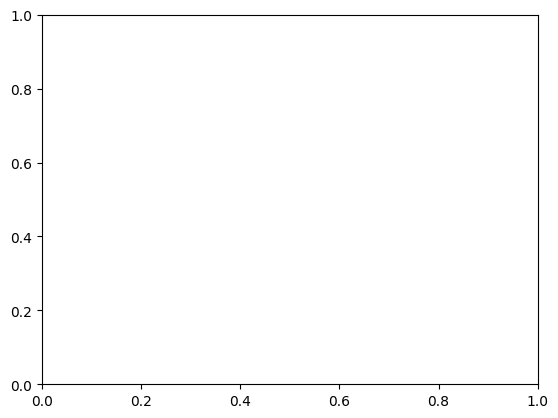

In [23]:
sc.pl.umap(adata, color='true_phenotype')

In [ ]:
sc.pl.umap(adata, color='leiden_res0_8')

In [ ]:
n = adata.obs['sample_id'].nunique()
colors = [plt.cm.hsv(i / n) for i in range(n)]
adata.uns['sample_id_colors'] = [mcolors.to_hex(c) for c in colors]

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sc.pl.umap(adata, color='sample_id', legend_fontsize=4, ax=ax, show=False)
plt.tight_layout()
plt.show()

In [ ]:
sc.pl.matrixplot(adata, var_names=adata.var_names, groupby='cell_type', cmap='vlag', dendrogram=True, use_raw=False,
                 standard_scale='var'
                 )

In [ ]:
sc.pl.matrixplot(adata, var_names=adata.var_names, groupby='cell_labels', cmap='vlag', dendrogram=True, use_raw=False,
                 standard_scale='var'
                 )

In [ ]:
sc.pp.combat(adata, key='sample_id')

In [ ]:
df = adata.to_df()
for col in adata.obs.columns:
    df[col] = adata.obs[col]

In [ ]:
df

In [ ]:
adata.X

In [ ]:
df.to_csv('../../../data/processed/IMMUcan/IMMUcan_quantification_combat.csv', index=False)

# Harmonize celltype labels

In [ ]:
df = pd.read_csv('../../../data/processed/IMMUcan/IMMUcan_quantification_combat.csv')


In [ ]:
df.columns

In [ ]:
df['cell_type'] = df['cell_type'].replace({'Tumor' : 'Cancer', 'Mural':'Stroma', 'CD8':'CD8+_T_cell', 'MacCD163':'M2_Macrophage',
                                           'CD4':'CD4+_T_cell', 'plasma':'Plasma_cell','DC':'Dendritic_cell', 'B':'B_cell',
                                           'NK':'NK_cell', 'pDC':'Plasmacytoid_dendritic_cell'})
df['cell_labels'] = df['cell_labels'].replace({'Tumor' : 'Cancer', 'Mural':'Stroma', 'CD8':'CD8+_T_cell', 'MacCD163':'M2_Macrophage',
                                             'CD4':'CD4+_T_cell', 'plasma':'Plasma_cell','DC':'Dendritic_cell', 'B':'B_cell',
                                                'NK':'NK_cell', 'pDC':'Plasmacytoid_dendritic_cell'})
df['cell_type'].value_counts()

In [ ]:
df.to_csv('../../../data/processed/IMMUcan/IMMUcan_quantification_combat.csv', index=False)

# Implement different levels of granularity

In [ ]:
df = pd.read_csv('../../../data/processed/IMMUcan/IMMUcan_quantification_combat.csv')
df['cell_type'].value_counts()

In [ ]:
df.columns

In [ ]:
df['level_2_cell_type'] = df['cell_type']
df['level_2_cell_type'] = df['level_2_cell_type'].replace({'CD8+_T_cell':'Lymphoid_immune', 'M2_Macrophage':'Myeloid_immune', 'CD4+_T_cell':'Lymphoid_immune', 'Plasma_cell':'Lymphoid_immune',
                                                           'Neutrophil':'Myeloid_immune', 'BnT':'Lymphoid_immune', 'Treg':'Lymphoid_immune', 'Dendritic_cell':'Myeloid_immune', 'B_cell':'Lymphoid_immune',
                                                           'NK_cell':'Lymphoid_immune', 'Plasmacytoid_dendritic_cell':'Myeloid_immune'})
df['level_2_cell_type'].value_counts()

In [ ]:
df['level_1_cell_type'] = df['level_2_cell_type']
df['level_1_cell_type'] = df['level_1_cell_type'].replace({'Lymphoid_immune':'Immune', 'Myeloid_immune':'Immune', 'Stroma':'Stromal'})
df['level_1_cell_type'].value_counts()

In [ ]:
df = reorder_columns(df, 'cell_type', 'level_1_cell_type')
df = reorder_columns(df, 'level_2_cell_type', 'level_1_cell_type')
df 

In [ ]:
df.to_csv('../../../data/processed/IMMUcan/IMMUcan_quantification_combat.csv', index=False)

# Encode uninfomrative variables with different dtypes

In [ ]:
df = pd.read_csv('../../../data/processed/IMMUcan/IMMUcan_quantification_combat.csv')
df.columns

In [ ]:
df['cell_type'].nunique()

In [ ]:
df = df.rename(columns={'ObjectNumber': 'cell_id'})

In [ ]:
df.to_csv('../../../data/processed/IMMUcan/IMMUcan_quantification_combat.csv', index=False)

# Bin celltypes

In [ ]:
df = pd.read_csv('../../../data/processed/IMMUcan/IMMUcan_quantification_combat.csv')
df['cell_type'].value_counts()

In [ ]:
#df['cell_type'] = df['cell_type'].replace({'HLADR':'undefined'})
df['level_1_cell_type'] = df['level_1_cell_type'].replace({'HLADR':'undefined'})
df['level_2_cell_type'] = df['level_2_cell_type'].replace({'HLADR':'undefined'})
df['cell_type'].value_counts()

In [ ]:
df.to_csv('../../../data/processed/IMMUcan/IMMUcan_quantification_combat.csv', index=False)